# DZO Assignment: Pointwise operations, Equalization and Histogram Matching


## Intensity transforms

First we will deal with intensity transforms. These are simple pointwise operations where each pixel's intensity `i` is transformed by a transformation `T` to a new intensity `T(i)`. 

We will work with grayscale 8-bit images for which the intensities are integers in range <0, 255>. 
The transformation `T` will be represented as a lookup table - a 1D numpy array of type `np.uint8`. 

Let us try this on an example. 

In [1]:
%load_ext autoreload
%autoreload 2

from pointwise import *
from DZO.utils import load_test_image, uint8_to_float01, float01_to_uint8

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
!pip3 install --upgrade --force-reinstall numpy pandas
import pandas as pd

  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl (10.8 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.1.post1
    Uninstalling pytz-2026.1.post1:
      Successfully uninstalled pytz-2026.1.post1
  Attempting

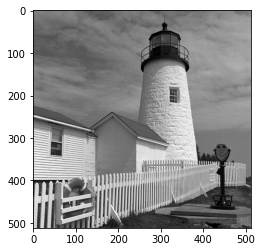

In [ ]:
im = load_test_image('lighthouse.png')
# make a bit dirty conversion to gray: 
im = im.mean(axis=2).astype(np.uint8)
plt.imshow(im, cmap='gray')

We have an image, now let's create an identity LUT (this one will transform the image so that it will look exactly the same)

Equality test passed.


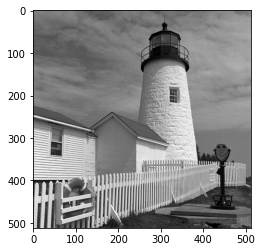

In [3]:
# identity LUT:
LUT = np.arange(256, dtype=np.uint8)

# transform an image and display it: 
plt.imshow(LUT[im], cmap='gray')

# make sure this is indeed an identity transform 
assert( np.all(im == LUT[im]) )
print('Equality test passed.')

Let us try a more interesting LUT.  

In [1]:
LUT1 = 0.1*np.arange(51) # beginning of LUT
# (note: try to change this constant 0.1 to different choices [e.g. 0.5, 1, 1.8])
LUT3 = LUT1 + 255 - LUT1[-1] # end of LUT 
LUT2 = np.linspace(LUT1[-1], LUT3[0], 256 - len(LUT1) - len(LUT3)) # middle of LUT
LUT = np.r_[LUT1, LUT2, LUT3].astype(np.uint8)
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(LUT); plt.title('LUT')
plt.subplot(1, 2, 2)
plt.imshow(LUT[im], cmap='gray'); plt.title('transformed image')

NameError: name 'np' is not defined

## Task 
Your task is to implement three different LUTs in function `get_LUT`: `negative`, `gamma` and `quantization`. 

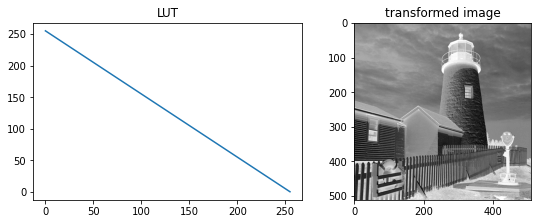

In [5]:
LUT = get_LUT('negative')
show_transformed(im, LUT)

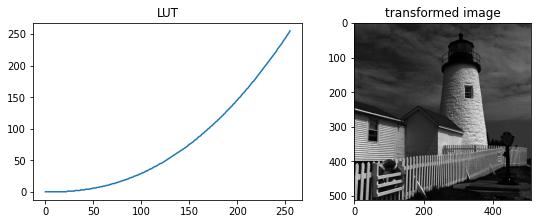

In [6]:
LUT = get_LUT('gamma', 2.3)
show_transformed(im, LUT)

min = 0 max = 255


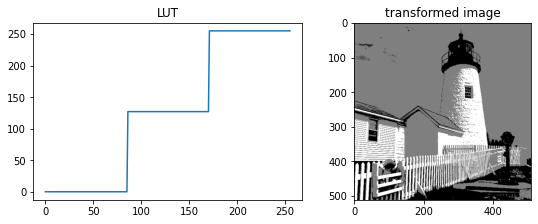

In [7]:
LUT = get_LUT('quantization', 3)
show_transformed(im, LUT)
print('min =', LUT.min(), 'max =', LUT.max())

## Intensity Equalization 

Equalizing an image consists of computing the LUT based on the image's CDF. 

As a preparation for this, implement the function `compute_histogram_and_cdf`. 

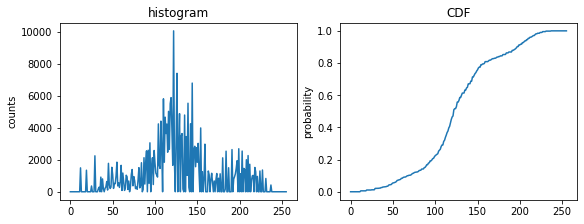

In [8]:
hist, cdf = compute_histogram_and_cdf(im)
plt.figure(figsize=(8, 3), constrained_layout = True)
plt.subplot(1, 2, 1); plt.plot(hist); plt.title('histogram'); plt.ylabel('counts')
plt.subplot(1, 2, 2); plt.plot(cdf); plt.title('CDF'); plt.ylabel('probability');


Now to only remaining step is to use `CDF` as `LUT`: 

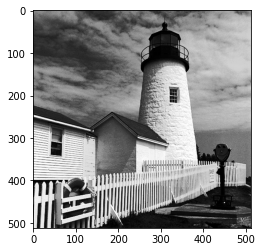

In [9]:
LUT_eq = float01_to_uint8(cdf)
plt.imshow(LUT_eq[im], cmap ='gray')

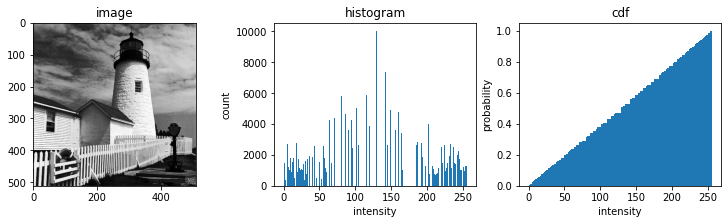

In [10]:
#Is the CDF of the equalized image really close to linear? 
show_image_hist_cdf(LUT_eq[im])


## Histogram matching 
Let us consider these two images: 

<img src="assets/hist_matching.png" width="800" style="background-color: white;">

These images were taken under two different camera settings. The right image has been edited manually to adjust its visual appearance. The goal is now to transform the gray levels of the left image so that it looks similar to the right image. This can be done by bringing the CDF of the left image as close as possible to the CDF of the right image. This is the core of the method called Histogram matching. 

How to do that? We know that every image can be intensity-normalized by equalization: 

<img src="assets/two_images_equalized.png" width="600" style="background-color: white;">

To bring the input image's CDF close to the target image CDF, all what's needed is to do a similar transformation as in equalization - the only difference is that for equalization, the target CDF is linear, while for histogram matching, the target CDF has a specific form implied by the input image. 

<img src="assets/hist_matching_process.png" width="800" style="background-color: white;">

That is, for each input image intensity `i_input` we find the corresponding `i_target` for which `CDF(i_input) == CDF(i_output)`, and use . Of course, due to discrete nature of the problem the equality can't hold exactly. Therefore, we always find a nearest neighbor. 

Your last task is then to implement a function `histogram_matching` which does just that. 






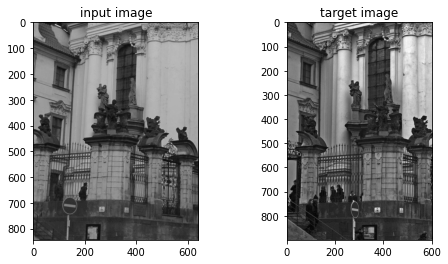

In [11]:
from DZO.utils import imread
im = imread('histmatch_input.jpg', convert_to_gray=True)
im_target = imread('histmatch_target.jpg', convert_to_gray = True)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(im, cmap='gray'); plt.title('input image')
plt.subplot(1, 2, 2); plt.imshow(im_target, cmap='gray'); plt.title('target image');


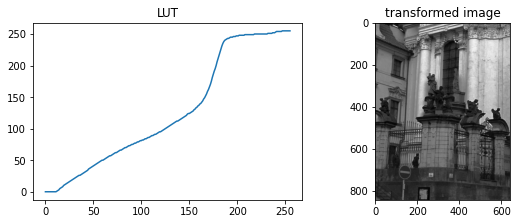

In [12]:
matching_LUT = histogram_matching(im, im_target)
show_transformed(im, matching_LUT)


Let us try that on another example of syntetically generated images:


The max intensity difference between im_target and transformed im is: 1 


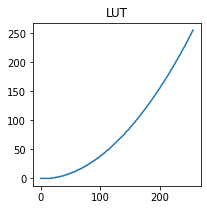

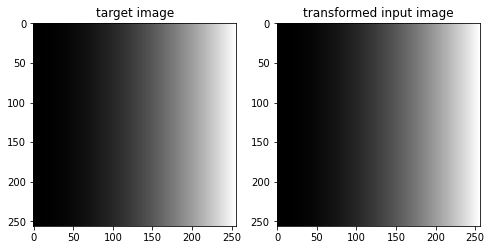

In [13]:

im = np.stack( (np.arange(256, dtype=np.uint8),) * 256, axis = 0)
im_target = np.stack( (np.arange(256)**2 / (255),) * 256, axis = 0).astype(np.uint8)
matching_LUT = histogram_matching(im, im_target)

max_diff = np.abs( im_target.astype(float) - matching_LUT[im] ).max().astype(np.uint8)
print(f'The max intensity difference between im_target and transformed im is: {max_diff} ')

plt.figure(figsize=(3, 3)) 
plt.plot(matching_LUT); plt.title('LUT')

plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1); plt.imshow(im_target, cmap='gray'); plt.title('target image')
plt.subplot(1, 2, 2); plt.imshow(matching_LUT[im], cmap='gray'); plt.title('transformed input image');
